In [2]:

path = '/home/apollo/Documents/github_projects/ripple_sync/'

scripts_path = path + '/scripts/'
tables_path = path + '/tables/'
figures_path = path + '/figures/'
results_path = path + '/results/'


In [3]:

import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
# import dabest

from statsmodels.stats.proportion import proportions_chisquare

%matplotlib widget

import helper_functions as hf


In [44]:

import warnings

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")


In [45]:

import statsmodels.api as sm
import statsmodels.formula.api as smf


In [46]:
from scipy.spatial.distance import euclidean


In [47]:

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [48]:
import numpy as np

def hedges_g(group1, group2):
    # Calculate means and standard deviations
    mean1, mean2 = np.nanmean(group1), np.nanmean(group2)
    std1, std2 = np.nanstd(group1, ddof=1), np.nanstd(group2, ddof=1)  # ddof=1 for sample std
    
    # Sample sizes
    n1, n2 = len(group1), len(group2)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    
    # Cohen's d
    cohen_d = (mean1 - mean2) / pooled_std
    
    # Correction factor for small sample sizes
    correction_factor = 1 - (3 / (4 * (n1 + n2) - 9))
    
    # Hedges' g
    hedges_g_value = cohen_d * correction_factor
    
    return hedges_g_value


In [49]:
from scipy.stats import wasserstein_distance

os.chdir(tables_path + '/figure_5/')
filename = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal.csv'
# filename = 'Figure_Ripple_PhasePhaseCoupling_RippleEpochs.csv'
df = pd.read_csv(filename)
df = df[df['shanks_distance'] != 1400]

shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)
df

phase_phase_difference_type = []
phase_phase_rat = []
phase_phase_session = []
phase_phase_effect_size = []
for ses in np.unique(df['session']):
    I_session = df['session']== ses
    rat = np.unique(df['rat'][I_session])[0]
    I_ipsi = df['side'] == 'ipsi'
    I_contra = df['side'] == 'contra'

    phase_phase_difference_type.append('phase_phase')
    phase_phase_rat.append(rat)
    phase_phase_session.append(ses)

    ipsi_phase_phase = df['phase_phase_coupling'][I_session&I_ipsi].values
    contra_phase_phase = df['phase_phase_coupling'][I_session&I_contra].values
    
    hedges_g_value = hedges_g(ipsi_phase_phase, contra_phase_phase)
    phase_phase_effect_size.append(hedges_g_value)
phase_phase_effect_size = np.array(phase_phase_effect_size)


os.chdir(tables_path + '/figure_5/')
# os.chdir(results_path)

filename = 'Figure_Ripple_AmpAmpCoupling_WholeSignal.csv'
# filename = 'Figure_Ripple_AmpAmpCoupling_RippleEpochs.csv'
df = pd.read_csv(filename)
df = df[df['shanks_distance'] != 1400]

shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)

amp_amp_difference_type = []
amp_amp_rat = []
amp_amp_session = []
amp_amp_effect_size = []
for ses in np.unique(df['session']):
    I_session = df['session']== ses
    rat = np.unique(df['rat'][I_session])[0]
    I_ipsi = df['side'] == 'ipsi'
    I_contra = df['side'] == 'contra'
    
    amp_amp_difference_type.append('amp_amp')
    amp_amp_rat.append(rat)
    amp_amp_session.append(ses)

    ipsi_amp_amp = df['r_value'][I_session&I_ipsi].values
    contra_amp_amp = df['r_value'][I_session&I_contra].values

    hedges_g_value = hedges_g(ipsi_amp_amp, contra_amp_amp)
    amp_amp_effect_size.append(hedges_g_value)
amp_amp_effect_size = np.array(amp_amp_effect_size)

difference_type = np.concatenate([phase_phase_difference_type,amp_amp_difference_type])
differences = np.concatenate([phase_phase_effect_size,amp_amp_effect_size])
rat_label = np.concatenate([phase_phase_rat,amp_amp_rat])
session_label = np.concatenate([phase_phase_session,amp_amp_session])

df = pd.DataFrame({'rat':rat_label,'session':session_label,'difference_type':difference_type,'differences':differences})
df

,rat,session,difference_type,differences
0,Ach,Achilles_10252013,phase_phase,6.011651
1,Ach,Achilles_11012013,phase_phase,5.599339
2,Bud,Buddy_06272013,phase_phase,4.380263
3,Cic,Cicero_09012014,phase_phase,5.851494
4,Cic,Cicero_09102014,phase_phase,6.226828
5,Cic,Cicero_09172014,phase_phase,5.453712
6,Gat,Gatsby_08022013,phase_phase,3.249207
7,Gat,Gatsby_08282013,phase_phase,1.476500
8,Ach,Achilles_10252013,amp_amp,5.324082
9,Ach,Achilles_11012013,amp_amp,4.583996


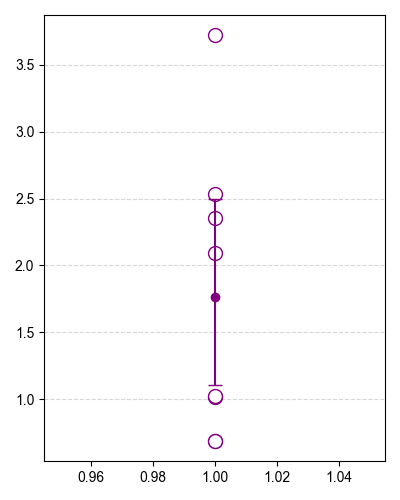

95% Confidence Interval: [1.109, 2.501]


In [50]:

# ratio = phase_phase_effect_size / amp_amp_effect_size
ratio = phase_phase_effect_size-amp_amp_effect_size

n_iterations = 5000
n_samples = len(phase_phase_effect_size)

bootstrap_ratios = []
for _ in range(n_iterations):
    indices = np.random.randint(0, n_samples, n_samples)
    # resampled_ratio = (phase_phase_effect_size[indices] / amp_amp_effect_size[indices]).mean()
    resampled_ratio = (phase_phase_effect_size[indices] - amp_amp_effect_size[indices]).mean()

    bootstrap_ratios.append(resampled_ratio)

lower_bound = np.percentile(bootstrap_ratios, 2.5)
upper_bound = np.percentile(bootstrap_ratios, 97.5)

plt.figure(figsize=(4,5))
plt.plot(
    np.ones(n_samples),
    ratio,
    marker='o',
    ls='',
    markerfacecolor='white',
    markeredgecolor='purple',
    markersize=10,
    label='Ratio'
)
plt.errorbar(
    1, ratio.mean(), yerr=[[ratio.mean() - lower_bound], [upper_bound - ratio.mean()]],
    fmt='o', color='purple', capsize=5, label='95% CI'
)
# plt.ylim([0,4])
plt.legend([], [], frameon=False)

plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.tight_layout()


os.chdir(figures_path + '/figure_5/')
fig_name = 'Figure_coupling_phasephase_ampamp_effect.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)


print(f"95% Confidence Interval: [{lower_bound:.3f}, {upper_bound:.3f}]")


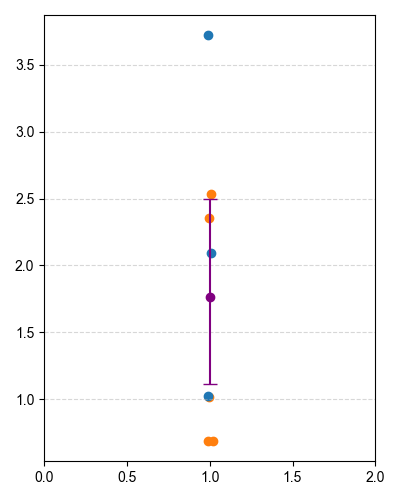

95% Confidence Interval: [1.113, 2.497]


In [51]:
labels = np.array(['linear','linear','linear','linear','circular','circular','linear','circular'])

# Step 1: assign unique colors to each label
unique_labels = np.unique(labels)
cmap = plt.get_cmap('tab10')  # categorical colormap
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}


# ratio = phase_phase_effect_size / amp_amp_effect_size
ratio = phase_phase_effect_size-amp_amp_effect_size

n_iterations = 5000
n_samples = len(phase_phase_effect_size)

bootstrap_ratios = []
for _ in range(n_iterations):
    indices = np.random.randint(0, n_samples, n_samples)
    # resampled_ratio = (phase_phase_effect_size[indices] / amp_amp_effect_size[indices]).mean()
    resampled_ratio = (phase_phase_effect_size[indices] - amp_amp_effect_size[indices]).mean()

    bootstrap_ratios.append(resampled_ratio)

lower_bound = np.percentile(bootstrap_ratios, 2.5)
upper_bound = np.percentile(bootstrap_ratios, 97.5)

plt.figure(figsize=(4,5))
x_coords = [1]

for i in range(ratio.shape[0]):
    lab = labels[i]
    color = color_map[lab]
    
    jitter_strength = 0.02  # Adjust the strength of jitter
    x_values = np.random.randn(1) * jitter_strength
    plt.scatter(x_coords+x_values, ratio[i], color=color, edgecolor=color)
    
    # plt.plot(
    #     x_coords,
    #     ratio,
    #     marker='o',
    #     ls='',
    #     markerfacecolor='white',
    #     markeredgecolor=color_map,
    #     markersize=10
    # )

    
plt.errorbar(
    1, ratio.mean(), yerr=[[ratio.mean() - lower_bound], [upper_bound - ratio.mean()]],
    fmt='o', color='purple', capsize=5, label='95% CI'
)
# plt.ylim([0,4])
plt.xlim([0,2])
plt.legend([], [], frameon=False)

plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.tight_layout()


os.chdir(figures_path + '/figure_5/')
fig_name = 'Figure_coupling_phasephase_ampamp_effect.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)


print(f"95% Confidence Interval: [{lower_bound:.3f}, {upper_bound:.3f}]")







In [52]:
from scipy import stats

# Perform a one-sample t-test against the value 1
t_stat, p_value = stats.ttest_rel(amp_amp_effect_size,phase_phase_effect_size)

# Calculate the mean of the ratios for plotting
mean_ratio = np.nanmean(ratio)

# Print results
print(f"Mean Ratio: {mean_ratio:.3f}")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.3f}")


Mean Ratio: 1.765
T-statistic: -4.582, P-value: 0.003


In [14]:
p_value

0.0025372454869696586

In [16]:
from scipy import stats

# Perform a one-sample t-test against the value 1
t_stat, p_value = stats.ttest_1samp(ratio,popmean=0)

# Calculate the mean of the ratios for plotting
mean_ratio = np.nanmean(ratio)

# Print results
print(f"Mean Ratio: {mean_ratio:.3f}")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.5f}")


Mean Ratio: 1.765
T-statistic: 4.582, P-value: 0.00254


In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm


# Define the formula for the mixed-effects model
formula = "differences ~ C(difference_type, Treatment(reference='amp_amp'))"
re_formula = "1"  # Random intercept for sessions
vc_formula = {"session": "0 + session"}  # Random effect of session

# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, data=df, groups='rat', re_formula=re_formula, vc_formula=vc_formula)
result = model.fit()

# Print summary of the model
print(result.summary())
print(result.pvalues)

                                  Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 differences
No. Observations:                  16                      Method:                             REML       
No. Groups:                        4                       Scale:                              0.5935     
Min. group size:                   2                       Log-Likelihood:                     -23.6259   
Max. group size:                   6                       Converged:                          Yes        
Mean group size:                   4.0                                                                    
----------------------------------------------------------------------------------------------------------
                                                                  Coef. Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------------------------

In [53]:


from scipy.stats import wasserstein_distance

os.chdir(tables_path + '/figure_5/')
filename = 'Figure_Ripple_CrossCorrelation_Filtered_Signal.csv'
df = pd.read_csv(filename)
df = df[df['shanks_distance'] != 1400]

shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)
df

phase_phase_difference_type = []
phase_phase_rat = []
phase_phase_session = []
phase_phase_effect_size = []
for ses in np.unique(df['session']):
    I_session = df['session']== ses
    rat = np.unique(df['rat'][I_session])[0]
    I_ipsi = df['side'] == 'ipsi'
    I_contra = df['side'] == 'contra'

    phase_phase_difference_type.append('phase_phase')
    phase_phase_rat.append(rat)
    phase_phase_session.append(ses)

    ipsi_phase_phase = df['max_correlation'][I_session&I_ipsi].values
    contra_phase_phase = df['max_correlation'][I_session&I_contra].values
    
    hedges_g_value = hedges_g(ipsi_phase_phase, contra_phase_phase)
    phase_phase_effect_size.append(hedges_g_value)
phase_phase_effect_size = np.array(phase_phase_effect_size)


os.chdir(tables_path + '/figure_5/')

filename = 'Figure_Ripple_CrossCorrelation_AmpEnv.csv'
df = pd.read_csv(filename)
df = df[df['shanks_distance'] != 1400]

shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)

amp_amp_difference_type = []
amp_amp_rat = []
amp_amp_session = []
amp_amp_effect_size = []
for ses in np.unique(df['session']):
    I_session = df['session']== ses
    rat = np.unique(df['rat'][I_session])[0]
    I_ipsi = df['side'] == 'ipsi'
    I_contra = df['side'] == 'contra'
    
    amp_amp_difference_type.append('amp_amp')
    amp_amp_rat.append(rat)
    amp_amp_session.append(ses)

    ipsi_amp_amp = df['max_correlation'][I_session&I_ipsi].values
    contra_amp_amp = df['max_correlation'][I_session&I_contra].values

    hedges_g_value = hedges_g(ipsi_amp_amp, contra_amp_amp)
    amp_amp_effect_size.append(hedges_g_value)
amp_amp_effect_size = np.array(amp_amp_effect_size)

difference_type = np.concatenate([phase_phase_difference_type,amp_amp_difference_type])
differences = np.concatenate([phase_phase_effect_size,amp_amp_effect_size])
rat_label = np.concatenate([phase_phase_rat,amp_amp_rat])
session_label = np.concatenate([phase_phase_session,amp_amp_session])

df = pd.DataFrame({'rat':rat_label,'session':session_label,'difference_type':difference_type,'differences':differences})
df

,rat,session,difference_type,differences
0,Ach,Achilles_10252013,phase_phase,8.412088
1,Ach,Achilles_11012013,phase_phase,7.268907
2,Bud,Buddy_06272013,phase_phase,4.459598
3,Cic,Cicero_09012014,phase_phase,8.795802
4,Cic,Cicero_09102014,phase_phase,8.515181
5,Cic,Cicero_09172014,phase_phase,7.520298
6,Gat,Gatsby_08022013,phase_phase,2.384976
7,Gat,Gatsby_08282013,phase_phase,1.642353
8,Ach,Achilles_10252013,amp_amp,4.281836
9,Ach,Achilles_11012013,amp_amp,3.955559


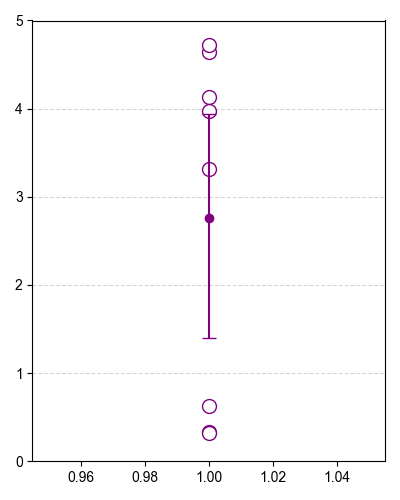

95% Confidence Interval: [1.396, 3.941]


In [54]:

# ratio = phase_phase_effect_size / amp_amp_effect_size
ratio = phase_phase_effect_size-amp_amp_effect_size

n_iterations = 5000
n_samples = len(phase_phase_effect_size)

bootstrap_ratios = []
for _ in range(n_iterations):
    indices = np.random.randint(0, n_samples, n_samples)
    # resampled_ratio = (phase_phase_effect_size[indices] / amp_amp_effect_size[indices]).mean()
    resampled_ratio = (phase_phase_effect_size[indices] - amp_amp_effect_size[indices]).mean()

    bootstrap_ratios.append(resampled_ratio)

lower_bound = np.percentile(bootstrap_ratios, 2.5)
upper_bound = np.percentile(bootstrap_ratios, 97.5)

plt.figure(figsize=(4,5))
plt.plot(
    np.ones(n_samples),
    ratio,
    marker='o',
    ls='',
    markerfacecolor='white',
    markeredgecolor='purple',
    markersize=10,
    label='Ratio'
)
plt.errorbar(
    1, ratio.mean(), yerr=[[ratio.mean() - lower_bound], [upper_bound - ratio.mean()]],
    fmt='o', color='purple', capsize=5, label='95% CI'
)
plt.ylim([0,5])
plt.legend([], [], frameon=False)

plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.tight_layout()


os.chdir(figures_path + '/figure_5/')
fig_name = 'Figure_crosscorrelation_phasephase_ampamp_effect.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)



print(f"95% Confidence Interval: [{lower_bound:.3f}, {upper_bound:.3f}]")


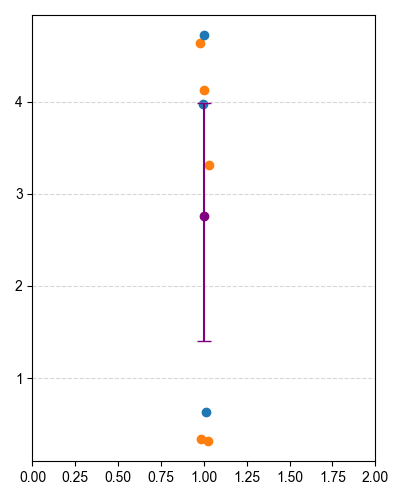

95% Confidence Interval: [1.406, 3.982]


In [55]:
labels = np.array(['linear','linear','linear','linear','circular','circular','linear','circular'])

# Step 1: assign unique colors to each label
unique_labels = np.unique(labels)
cmap = plt.get_cmap('tab10')  # categorical colormap
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}


# ratio = phase_phase_effect_size / amp_amp_effect_size
ratio = phase_phase_effect_size-amp_amp_effect_size

n_iterations = 5000
n_samples = len(phase_phase_effect_size)

bootstrap_ratios = []
for _ in range(n_iterations):
    indices = np.random.randint(0, n_samples, n_samples)
    # resampled_ratio = (phase_phase_effect_size[indices] / amp_amp_effect_size[indices]).mean()
    resampled_ratio = (phase_phase_effect_size[indices] - amp_amp_effect_size[indices]).mean()

    bootstrap_ratios.append(resampled_ratio)

lower_bound = np.percentile(bootstrap_ratios, 2.5)
upper_bound = np.percentile(bootstrap_ratios, 97.5)

plt.figure(figsize=(4,5))
x_coords = [1]

for i in range(ratio.shape[0]):
    lab = labels[i]
    color = color_map[lab]
    
    jitter_strength = 0.02  # Adjust the strength of jitter
    x_values = np.random.randn(1) * jitter_strength
    plt.scatter(x_coords+x_values, ratio[i], color=color, edgecolor=color)
    
    # plt.plot(
    #     x_coords,
    #     ratio,
    #     marker='o',
    #     ls='',
    #     markerfacecolor='white',
    #     markeredgecolor=color_map,
    #     markersize=10
    # )

    
plt.errorbar(
    1, ratio.mean(), yerr=[[ratio.mean() - lower_bound], [upper_bound - ratio.mean()]],
    fmt='o', color='purple', capsize=5, label='95% CI'
)
# plt.ylim([0,4])
plt.xlim([0,2])
plt.legend([], [], frameon=False)

plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.tight_layout()


os.chdir(figures_path + '/figure_5/')
fig_name = 'Figure_coupling_phasephase_ampamp_effect.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)


print(f"95% Confidence Interval: [{lower_bound:.3f}, {upper_bound:.3f}]")





In [42]:
from scipy import stats

# Perform a one-sample t-test against the value 1
t_stat, p_value = stats.ttest_rel(phase_phase_effect_size,amp_amp_effect_size)

# Calculate the mean of the ratios for plotting
mean_ratio = np.nanmean(ratio)

# Print results
print(f"Mean Ratio: {mean_ratio:.3f}")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.3f}")

Mean Ratio: 2.757
T-statistic: 3.940, P-value: 0.006


In [43]:
from scipy import stats

# Perform a one-sample t-test against the value 1
t_stat, p_value = stats.ttest_1samp(ratio,popmean=0)

# Calculate the mean of the ratios for plotting
mean_ratio = np.nanmean(ratio)

# Print results
print(f"Mean Ratio: {mean_ratio:.3f}")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.5f}")


Mean Ratio: 2.757
T-statistic: 3.940, P-value: 0.00560


In [175]:
import pandas as pd
import numpy as np
import statsmodels.api as sm


# Define the formula for the mixed-effects model
formula = "differences ~ C(difference_type, Treatment(reference='phase_phase'))"
re_formula = "1"  # Random intercept for sessions
vc_formula = {"session": "0 + session"}  # Random effect of session

# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, data=df, groups='rat', re_formula=re_formula, vc_formula=vc_formula)
result = model.fit()

# Print summary of the model
print(result.summary())


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                                   Mixed Linear Model Regression Results
Model:                             MixedLM                  Dependent Variable:                  differences
No. Observations:                  16                       Method:                              REML       
No. Groups:                        4                        Scale:                               1.5762     
Min. group size:                   2                        Log-Likelihood:                      -28.5409   
Max. group size:                   6                        Converged:                           Yes        
Mean group size:                   4.0                                                                      
------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [176]:
result.pvalues

Intercept                                                            3.429861e-08
C(difference_type, Treatment(reference='phase_phase'))[T.amp_amp]    1.125793e-05
rat Var                                                              3.723328e-01
session Var                                                          9.997975e-01
dtype: float64

In [ ]:
# fazer uma figura comparando tamanho de efeito do phase-phase (e corr) 
# e amp-amp (e corr) ao lado de cada uma destas figuras

In [ ]:
# https://acclab.github.io/DABEST-python/tutorials/05-delta_delta.html

In [13]:

os.chdir(tables_path + '/figure_3/')
filename = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal.csv'
df_phase = pd.read_csv(filename)
df_phase = df_phase[df_phase['shanks_distance'] != 1400]
shank_mask = (df_phase['shank_1'] == 8) | (df_phase['shank_1'] == 10) | (df_phase['shank_2'] == 8) | (df_phase['shank_2'] == 10)
rat_mask = df_phase['rat'] == 'Bud'
df_phase = df_phase[~(shank_mask*rat_mask)]
df_phase['session'] = pd.Categorical(df_phase['session'])
df_phase['rat'] = pd.Categorical(df_phase['rat'])
df_phase['shanks_distance_units'] = df_phase['shanks_distance']/200
df_phase = df_phase.reset_index(drop=True)
df_phase



os.chdir(tables_path + '/figure_4/')
filename = 'Figure_Ripple_AmpAmpCoupling_WholeSignal.csv'
df_amp = pd.read_csv(filename)
df_amp = df_amp[df_amp['shanks_distance'] != 1400]
shank_mask = (df_amp['shank_1'] == 8) | (df_amp['shank_1'] == 10) | (df_amp['shank_2'] == 8) | (df_amp['shank_2'] == 10)
rat_mask = df_amp['rat'] == 'Bud'
df_amp = df_amp[~(shank_mask*rat_mask)]
df_amp['session'] = pd.Categorical(df_amp['session'])
df_amp['rat'] = pd.Categorical(df_amp['rat'])
df_amp['shanks_distance_units'] = df_amp['shanks_distance']/200
df_amp = df_amp.reset_index(drop=True)
df_amp

# long format

rat = np.concatenate([df_phase['rat'],df_amp['rat']])
session = np.concatenate([df_phase['session'],df_amp['session']])
side = np.concatenate([df_phase['side'],df_amp['side']])
analysis_values = np.concatenate([df_phase['phase_phase_coupling'],df_amp['r_value']])
analysis_type = np.repeat(['phase_phase','amp_amp'],[len(df_phase['phase_phase_coupling']),len(df_amp['r_value'])])


data_dict = {'rat':rat,
            'session':session,
            'side':side,
            'analysis_type':analysis_type,
            'analysis_values':analysis_values
            }
df = pd.DataFrame(data_dict)
df


,rat,session,side,analysis_type,analysis_values
0,Ach,Achilles_10252013,ipsi,phase_phase,0.692846
1,Ach,Achilles_10252013,ipsi,phase_phase,0.584654
2,Ach,Achilles_10252013,ipsi,phase_phase,0.500051
3,Ach,Achilles_10252013,ipsi,phase_phase,0.415421
4,Ach,Achilles_10252013,ipsi,phase_phase,0.343567
...,...,...,...,...,...
925,Gat,Gatsby_08282013,ipsi,amp_amp,0.946526
926,Gat,Gatsby_08282013,ipsi,amp_amp,0.881811
927,Gat,Gatsby_08282013,ipsi,amp_amp,0.959055
928,Gat,Gatsby_08282013,ipsi,amp_amp,0.887434


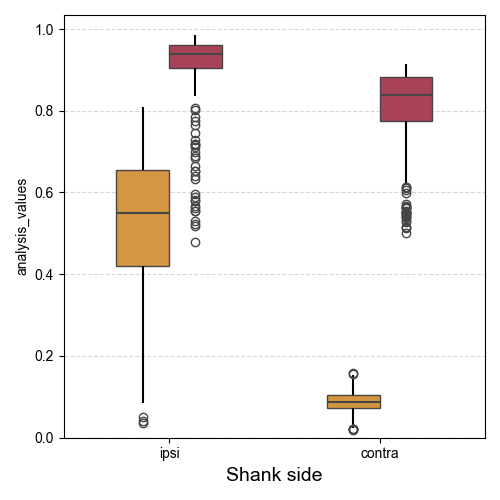

In [14]:

plt.figure(figsize=(5,5))
box = sns.boxplot(data=df, x='side', hue="analysis_type", y='analysis_values',
            order=["ipsi", "contra"], showfliers=True, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal)  # Using the custom color palette

plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim(bottom=0)
plt.tight_layout()
os.chdir(figures_path + '/figure_5/')

plt.show()



/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 83.7% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 81.4% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 93.9% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 70.9% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


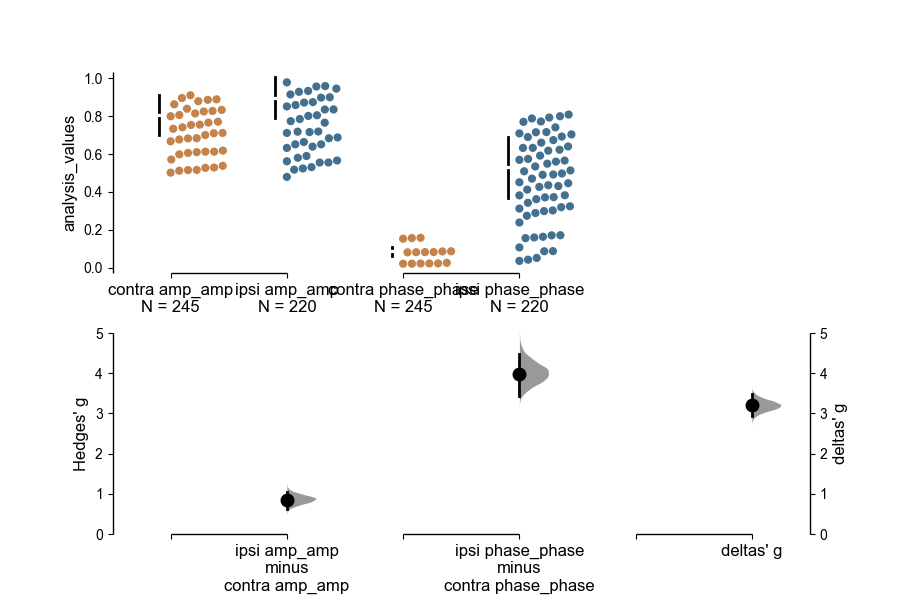

In [20]:
unpaired_delta2 = dabest.load(data = df, x = ["side", "side"], y = "analysis_values", delta2 = True, x1_level = ["contra", "ipsi"],
                              experiment_label = ["amp_amp", "phase_phase"], experiment = "analysis_type")
unpaired_delta2.delta_g.plot(delta2_ylim=[0,5]);

os.chdir(figures_path + '/figure_5/')
fig_name = 'Figure_phasephase_ampamp_effect_dabest.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)


In [36]:
# print(unpaired_delta2.delta_g)
unpaired_delta2.delta_g.delta_delta
# unpaired_delta2.delta_g.results.keys()

DABEST v2024.03.29
                  
Good afternoon!
The current time is Fri Sep 27 15:06:47 2024.

The deltas' g between amp_amp and phase_phase is 3.2 [95%CI 2.94, 3.48].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing the effect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

0.0

In [23]:

unpaired_delta2.delta_g.statistical_tests.pvalue_permutation

0    0.0
1    0.0
Name: pvalue_permutation, dtype: float64

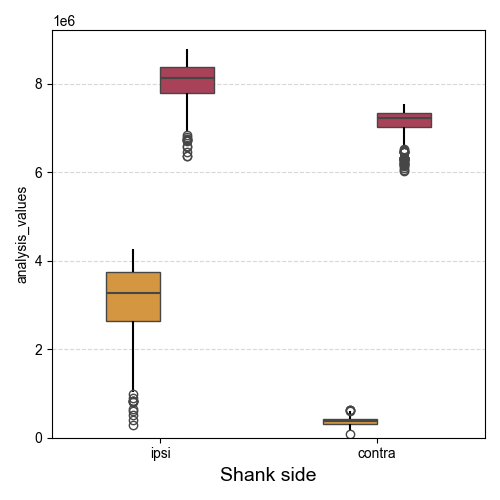

In [41]:


os.chdir(tables_path + '/figure_3/')
filename = 'Figure_Ripple_CrossCorrelation_Filtered_Signal.csv'
df_phase = pd.read_csv(filename)
df_phase = df_phase[df_phase['shanks_distance'] != 1400]
shank_mask = (df_phase['shank_1'] == 8) | (df_phase['shank_1'] == 10) | (df_phase['shank_2'] == 8) | (df_phase['shank_2'] == 10)
rat_mask = df_phase['rat'] == 'Bud'
df_phase = df_phase[~(shank_mask*rat_mask)]
df_phase['session'] = pd.Categorical(df_phase['session'])
df_phase['rat'] = pd.Categorical(df_phase['rat'])
df_phase['shanks_distance_units'] = df_phase['shanks_distance']/200
df_phase = df_phase.reset_index(drop=True)
df_phase

os.chdir(tables_path + '/figure_4/')
filename = 'Figure_Ripple_CrossCorrelation_AmpEnv.csv'
df_amp = pd.read_csv(filename)
df_amp = df_amp[df_amp['shanks_distance'] != 1400]
shank_mask = (df_amp['shank_1'] == 8) | (df_amp['shank_1'] == 10) | (df_amp['shank_2'] == 8) | (df_amp['shank_2'] == 10)
rat_mask = df_amp['rat'] == 'Bud'
df_amp = df_amp[~(shank_mask*rat_mask)]
df_amp['session'] = pd.Categorical(df_amp['session'])
df_amp['rat'] = pd.Categorical(df_amp['rat'])
df_amp['shanks_distance_units'] = df_amp['shanks_distance']/200
df_amp = df_amp.reset_index(drop=True)
df_amp

# long format

rat = np.concatenate([df_phase['rat'],df_amp['rat']])
session = np.concatenate([df_phase['session'],df_amp['session']])
side = np.concatenate([df_phase['side'],df_amp['side']])
analysis_values = np.concatenate([df_phase['max_correlation'],df_amp['max_correlation']])
analysis_type = np.repeat(['phase_phase','amp_amp'],[len(df_phase['max_correlation']),len(df_amp['max_correlation'])])


data_dict = {'rat':rat,
            'session':session,
            'side':side,
            'analysis_type':analysis_type,
            'analysis_values':analysis_values
            }
df = pd.DataFrame(data_dict)
df



plt.figure(figsize=(5,5))
box = sns.boxplot(data=df, x='side', hue="analysis_type", y='analysis_values',
            order=["ipsi", "contra"], showfliers=True, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal)  # Using the custom color palette

plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 92.2% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 87.3% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 97.6% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/dabest/plot_tools.py:1232: UserWarning: 81.8% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


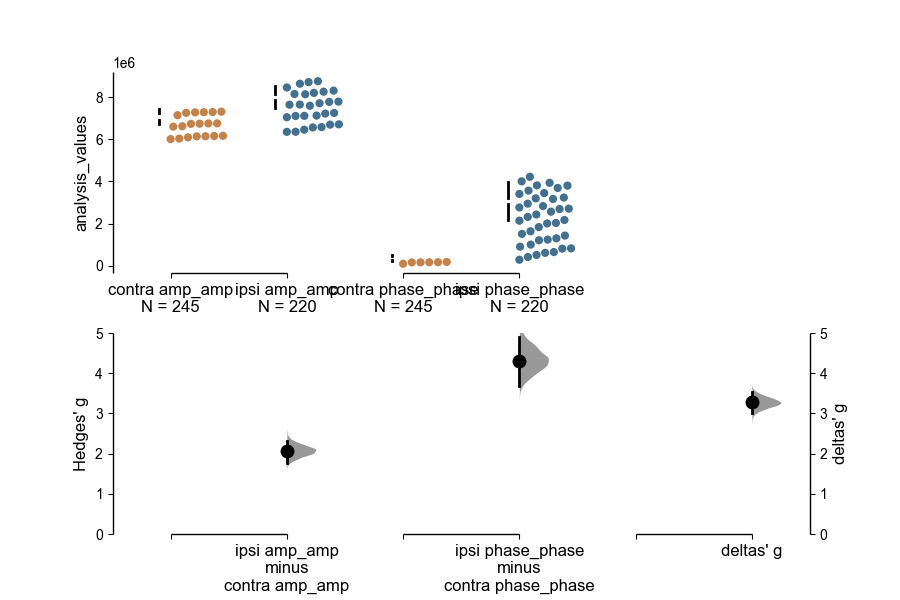

In [42]:

unpaired_delta2 = dabest.load(data = df, x = ["side", "side"], y = "analysis_values", delta2 = True, x1_level = ["contra", "ipsi"],
                              experiment_label = ["amp_amp", "phase_phase"], experiment = "analysis_type")
unpaired_delta2.delta_g.plot(delta2_ylim=[0,5]);

os.chdir(figures_path + '/figure_5/')
fig_name = 'Figure_CCfiltered_CCamp_effect_dabest.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)



In [44]:
print(unpaired_delta2.delta_g)
unpaired_delta2.delta_g.results


DABEST v2024.03.29
                  
Good afternoon!
The current time is Fri Sep 27 15:07:39 2024.

The unpaired deltas' g between contra amp_amp and ipsi amp_amp is 2.07 [95%CI 1.76, 2.32].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

The unpaired deltas' g between contra phase_phase and ipsi phase_phase is 4.31 [95%CI 3.68, 4.91].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

The deltas' g between amp_amp and phase_phase is 3.28 [95%CI 3.01, 3.55].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing the effect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid st

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,permutations,pvalue_permutation,permutation_count,permutations_var,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,contra amp_amp,ipsi amp_amp,245,220,deltas' g,None,2.065138,95,1.761677,2.320579,...,"[0.23072272720481096, 0.09316439710058, 0.0369...",0.0,5000,"[3491881291.3645277, 3566111584.0266323, 35753...",7.334641e-70,-21.879891,3.212665e-75,-22.270062,1.449124e-53,4658.0
1,contra phase_phase,ipsi phase_phase,245,220,deltas' g,None,4.311257,95,3.675841,4.910662,...,"[0.15378051869046053, 0.0932123572597399, -0.0...",0.0,5000,"[19070203858.385048, 19153517388.97983, 192072...",3.860292e-112,-44.099837,1.527834e-176,-46.491795,9.782426e-76,306.0


In [25]:
unpaired_delta2.delta_g.statistical_tests

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,contra amp_amp,ipsi amp_amp,245,220,deltas' g,None,2.065138,95,1.761677,2.320579,0.0,7.334641e-70,-21.879891,3.212665e-75,-22.270062,1.449124e-53,4658.0
1,contra phase_phase,ipsi phase_phase,245,220,deltas' g,None,4.311257,95,3.675841,4.910662,0.0,3.860292e-112,-44.099837,1.527834e-176,-46.491795,9.782426e-76,306.0
